# <u>TensorFlow: CIFAR10 CNN Tutorial</u>

In [20]:
import tensorflow as tf
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import itertools
import keras

print(tf.__version__)

2.19.0


In [21]:
cifar10 = tf.keras.datasets.cifar10
(X_train , Y_train) , (X_test , Y_test) = cifar10.load_data()

# Data Preprocessing

0. airplane
1. automobile
2. bird
3. cat
4. deer
5. dog
6. frog
7. horse
8. ship
9. truck

In [22]:
Y_train[0]

array([6], dtype=uint8)

In [23]:
X_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [24]:
Y_test = Y_test.flatten()
Y_train = Y_train.flatten()

/var/folders/t7/9x9qmn592xn0y4zzm31nrx5r0000gn/T/ipykernel_8790/188065452.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set(xticklabels = classes)


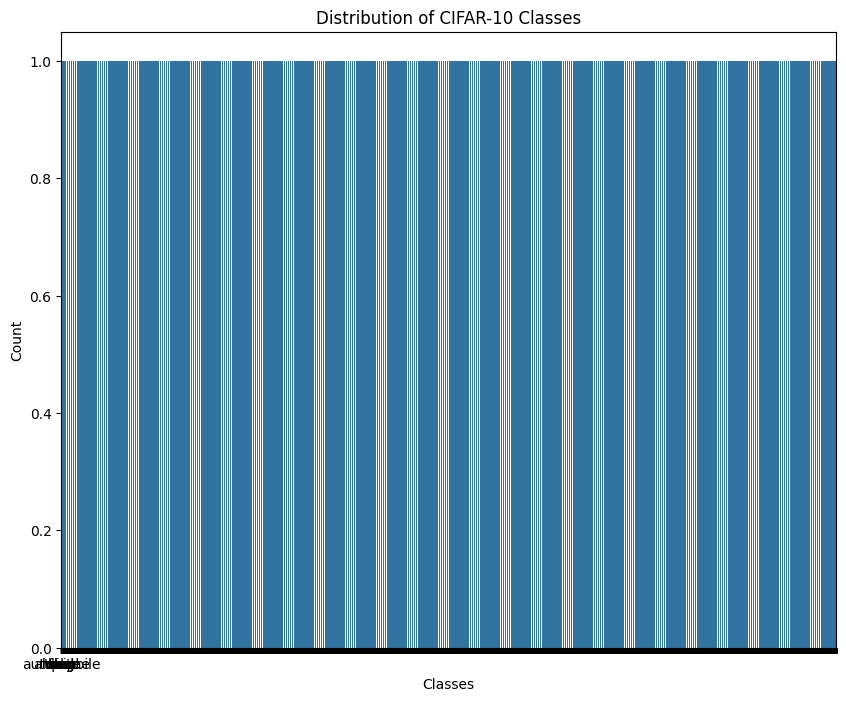

In [25]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10,8))
p = sns.countplot(Y_train.flatten())
p.set(xticklabels = classes)
plt.title('Distribution of CIFAR-10 Classes')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.show()

/var/folders/t7/9x9qmn592xn0y4zzm31nrx5r0000gn/T/ipykernel_8790/1202648978.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set(xticklabels=classes)


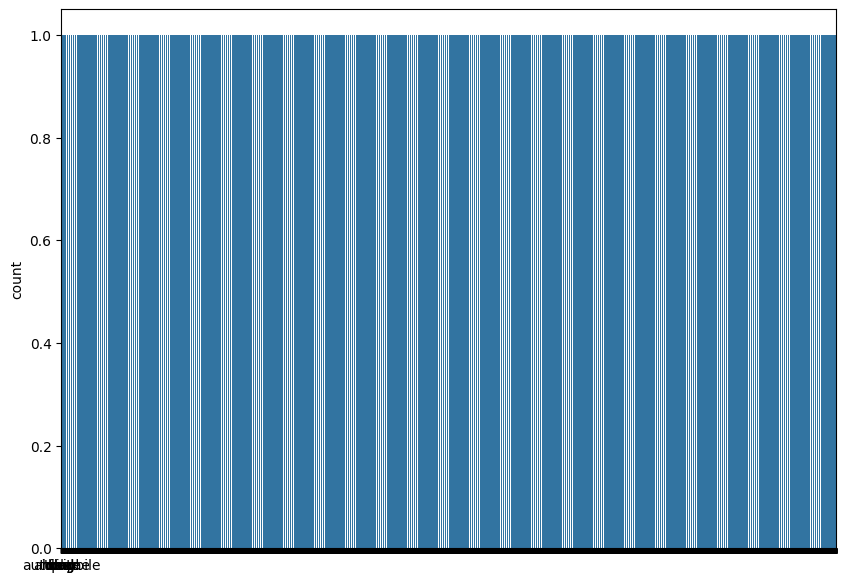

In [27]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,7))
p = sns.countplot(Y_train.flatten())
p.set(xticklabels=classes)
plt.show()

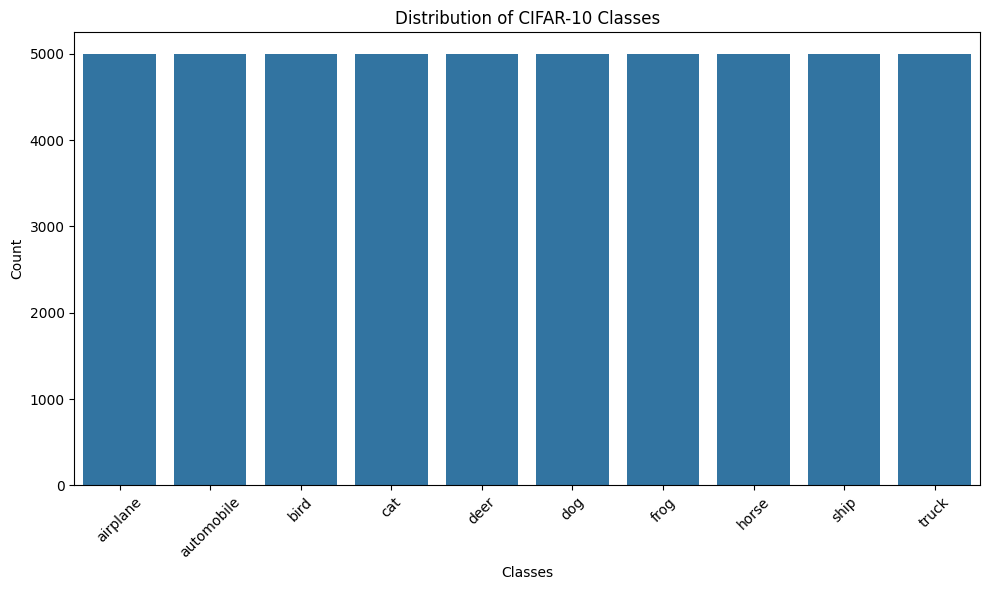

In [32]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,6))
p = sns.countplot(x=Y_train.flatten())

# Fix the x-axis ticks properly
p.set_xticks(range(len(classes)))
p.set_xticklabels(classes, rotation=45)  # Rotate for better visibility

plt.title('Distribution of CIFAR-10 Classes')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.tight_layout()  # Fix label clipping
plt.show()

# Check for NaN Values

In [37]:
np.isnan(X_train).any()

np.False_

In [38]:
np.isnan(X_test).any()

np.False_

# Normalization and Reshaping

In [39]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 3)
X_train = X_train/255
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 3)
X_test = X_test/255

# Label Encoding

In [40]:
Y_train = tf.one_hot(Y_train.astype(np.int32), depth=10)
Y_test = tf.one_hot(Y_test.astype(np.int32), depth=10)

In [43]:

Y_train[3]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.], dtype=float32)>

# Visualize Data

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

tf.Tensor([0. 0. 0. 0. 1. 0. 0. 0. 0. 0.], shape=(10,), dtype=float32)


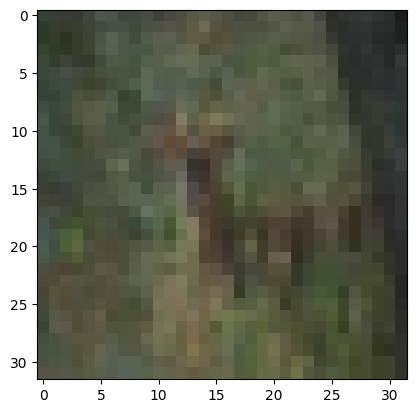

In [57]:
plt.imshow(X_train[10] , interpolation='nearest')
print(Y_train[10])

tf.Tensor([0. 0. 0. 1. 0. 0. 0. 0. 0. 0.], shape=(10,), dtype=float32)


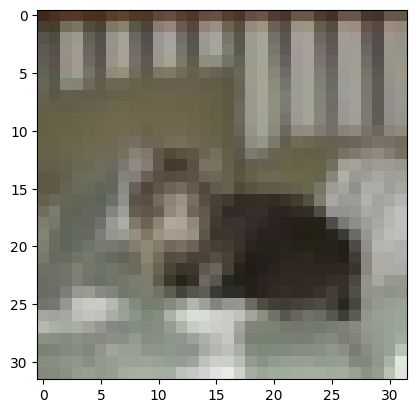

In [46]:
plt.imshow(X_train[150])
print(Y_train[150])

tf.Tensor([0. 0. 0. 0. 0. 0. 0. 0. 1. 0.], shape=(10,), dtype=float32)


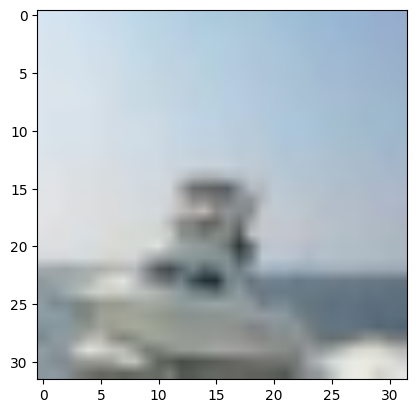

In [52]:
plt.imshow(X_train[100] , interpolation='bilinear')
print(Y_train[100])

tf.Tensor([0. 0. 0. 0. 0. 0. 1. 0. 0. 0.], shape=(10,), dtype=float32)


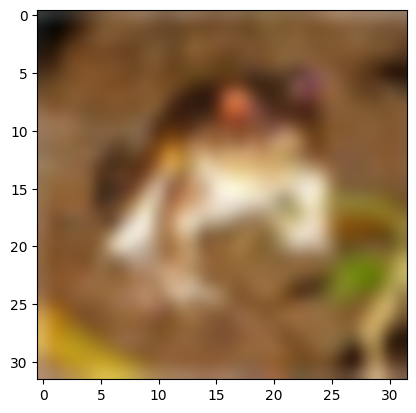

In [54]:
plt.imshow(X_train[0] , interpolation='bicubic')
print(Y_train[0])

# CNN

In [58]:
batch_size = 32
num_classes = 10
epochs = 50

In [62]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32,3, padding='same', activation ='relu' , input_shape=X_train.shape[1:]),
    tf.keras.layers.Conv2D(32,3, padding='same', activation ='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),
    
    tf.keras.layers.Conv2D(64,3, padding='same', activation ='relu'),
    tf.keras.layers.Conv2D(64,3, padding='same', activation ='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')])


model.compile(optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.0001, decay= 1e-6) , loss= 'categorical_crossentropy', metrics=['accuracy'])



/opt/miniconda3/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [63]:
history = model.fit(X_train, Y_train , batch_size=batch_size, epochs=epochs)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 97s 61ms/step - accuracy: 0.2658 - loss: 1.9885
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 95s 60ms/step - accuracy: 0.4454 - loss: 1.5318
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 97s 62ms/step - accuracy: 0.5149 - loss: 1.3580
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 701s 449ms/step - accuracy: 0.5587 - loss: 1.2379
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 101s 64ms/step - accuracy: 0.5953 - loss: 1.1448
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 99s 63ms/step - accuracy: 0.6182 - loss: 1.0760
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 99s 64ms/step - accuracy: 0.6432 - loss: 1.0089
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step - accuracy: 0.6586 - loss: 0.9705
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step - accuracy: 0.6792 - loss: 0.9206
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step - accuracy: 0.6879 - loss: 0.8825
Epoch 11/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 102s 65ms/step - accuracy: 0.7042 - loss: 0.8488
E

# Evaluate the Model

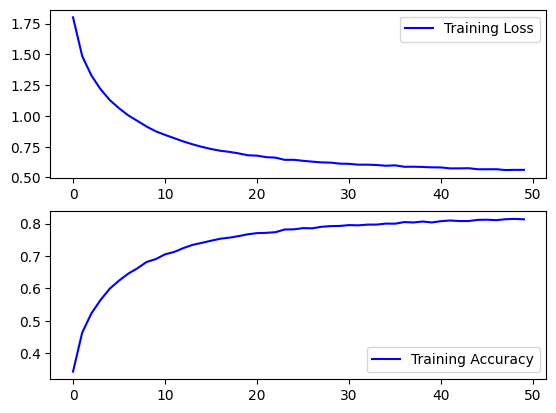

In [80]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,1)
ax[0].plot(history.history['loss'], color='blue', label ='Training Loss')
ax[0].legend()
ax[1].plot(history.history['accuracy'], color='blue', label='Training Accuracy')
ax[1].legend()
plt.show()

# Predict Results

In [81]:
test_loss, test_accuracy = model.evaluate(X_test, Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7903 - loss: 0.6325


Our model runs pretty well, with an accuracy of ~80% on our testing data.

# Confusion Matrix

In [82]:
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis = 1)
Y_test_classes = np.argmax(Y_test, axis = 1)

confussion_mxt = tf.math.confusion_matrix(Y_test_classes, Y_pred_classes)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


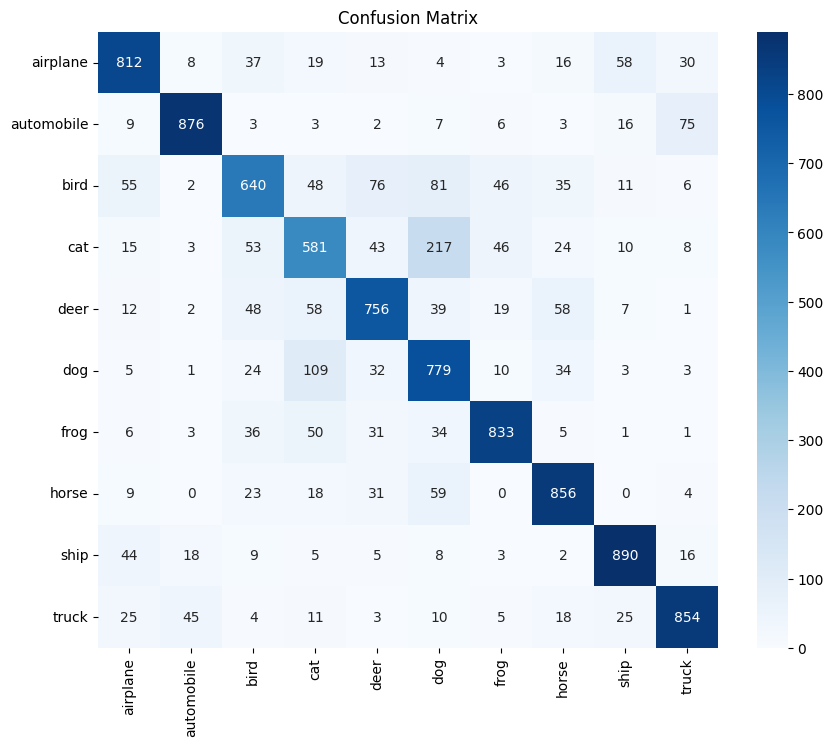

In [84]:
plt.figure(figsize=(10,8))
sns.heatmap(confussion_mxt, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.show()